# Beijing Air Quality Forecasting - Comprehensive Analysis

## Project Overview

This project focuses on forecasting PM2.5 air pollution levels in Beijing using Recurrent Neural Networks (RNNs) and Long Short-Term Memory (LSTM) models. PM2.5 (particulate matter with diameter less than 2.5 micrometers) is a critical air quality indicator that affects public health.

### Objectives:
1. Preprocess sequential air quality and weather data
2. Design and train RNN/LSTM models for accurate PM2.5 prediction
3. Fine-tune models through systematic experimentation
4. Achieve RMSE below 4000 on the leaderboard
5. Analyze model performance and address RNN-specific challenges

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, GRU, SimpleRNN
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1_l2

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:
# Load the datasets
# Loading from local data directory
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

print(f"Training data shape: {train.shape}")
print(f"Test data shape: {test.shape}")


Training data shape: (30676, 12)
Test data shape: (13148, 11)


In [5]:
# Display basic information about the datasets
print("DATASET OVERVIEW")
print("\nTraining Data Info:")
print(train.info())
print("\nTest Data Info:")
print(test.info())


DATASET OVERVIEW

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30676 entries, 0 to 30675
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   No        30676 non-null  int64  
 1   DEWP      30676 non-null  float64
 2   TEMP      30676 non-null  float64
 3   PRES      30676 non-null  float64
 4   Iws       30676 non-null  float64
 5   Is        30676 non-null  float64
 6   Ir        30676 non-null  float64
 7   datetime  30676 non-null  object 
 8   cbwd_NW   30676 non-null  float64
 9   cbwd_SE   30676 non-null  float64
 10  cbwd_cv   30676 non-null  float64
 11  pm2.5     28755 non-null  float64
dtypes: float64(10), int64(1), object(1)
memory usage: 2.8+ MB
None

Test Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13148 entries, 0 to 13147
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   No        13148 non-null  int6

# 1. DATA EXPLORATION AND ANALYSIS

## 1.1 Initial Data Inspection

Understanding the structure and content of our dataset is crucial before preprocessing. This section provides comprehensive statistics and visualizations to identify patterns, missing values, and relationships between features.

In [6]:

print("Column Names and Data Types:")
print(train.dtypes)
# Inspecting the first few rows of the dataset to understand its structure
print("Training Data - First 10 rows:")
print(train.head(10))

Column Names and Data Types:
No            int64
DEWP        float64
TEMP        float64
PRES        float64
Iws         float64
Is          float64
Ir          float64
datetime     object
cbwd_NW     float64
cbwd_SE     float64
cbwd_cv     float64
pm2.5       float64
dtype: object
Training Data - First 10 rows:
   No      DEWP      TEMP      PRES       Iws        Is        Ir  \
0   1 -1.580878 -1.922250  0.443328 -0.441894 -0.069353 -0.137667   
1   2 -1.580878 -2.004228  0.345943 -0.379306 -0.069353 -0.137667   
2   3 -1.580878 -1.922250  0.248559 -0.343514 -0.069353 -0.137667   
3   4 -1.580878 -2.168183  0.248559 -0.280926 -0.069353 -0.137667   
4   5 -1.511594 -2.004228  0.151174 -0.218339 -0.069353 -0.137667   
5   6 -1.442309 -1.840273  0.053790 -0.155751 -0.069353 -0.137667   
6   7 -1.442309 -1.758296  0.053790 -0.093164 -0.069353 -0.137667   
7   8 -1.442309 -1.758296  0.053790 -0.057371 -0.069353 -0.137667   
8   9 -1.442309 -1.758296  0.053790  0.005216 -0.069353 -0.137667

In [7]:
# Display column names
print(f"Target variable: pm2.5")
print(train.columns.tolist())
print(f"Features (excluding target): {len(train.columns) - 1}")


Target variable: pm2.5
['No', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'datetime', 'cbwd_NW', 'cbwd_SE', 'cbwd_cv', 'pm2.5']
Features (excluding target): 11


In [8]:
# Convert datetime column to datetime format and set as index
# This is essential for time-series analysis as it allows proper temporal ordering
train['datetime'] = pd.to_datetime(train['datetime'])
test['datetime'] = pd.to_datetime(test['datetime'])

# Set datetime as index for better time-series handling
train_original = train.copy()
test_original = test.copy()
train.set_index('datetime', inplace=True)
test.set_index('datetime', inplace=True)

print("Datetime conversion completed.")
print(f"Training data time range: {train.index.min()} to {train.index.max()}")
print(f"Test data time range: {test.index.min()} to {test.index.max()}")
print(f"Total time span (training): {(train.index.max() - train.index.min()).days} days")


Datetime conversion completed.
Training data time range: 2010-01-01 00:00:00 to 2013-07-02 03:00:00
Test data time range: 2013-07-02 04:00:00 to 2014-12-31 23:00:00
Total time span (training): 1278 days


## 1.2 Missing Values Analysis

Missing values can significantly impact model performance. We need to:
1. Identify which features have missing values
2. Understand the pattern of missingness (random vs. systematic)
3. Choose appropriate imputation strategies based on the nature of the data

MISSING VALUES ANALYSIS

Missing values in Training Data:
pm2.5    1921
dtype: int64

Total missing values in training: 1921
Percentage of missing values: 6.26%

Missing values in Test Data:
Series([], dtype: int64)

Total missing values in test: 0


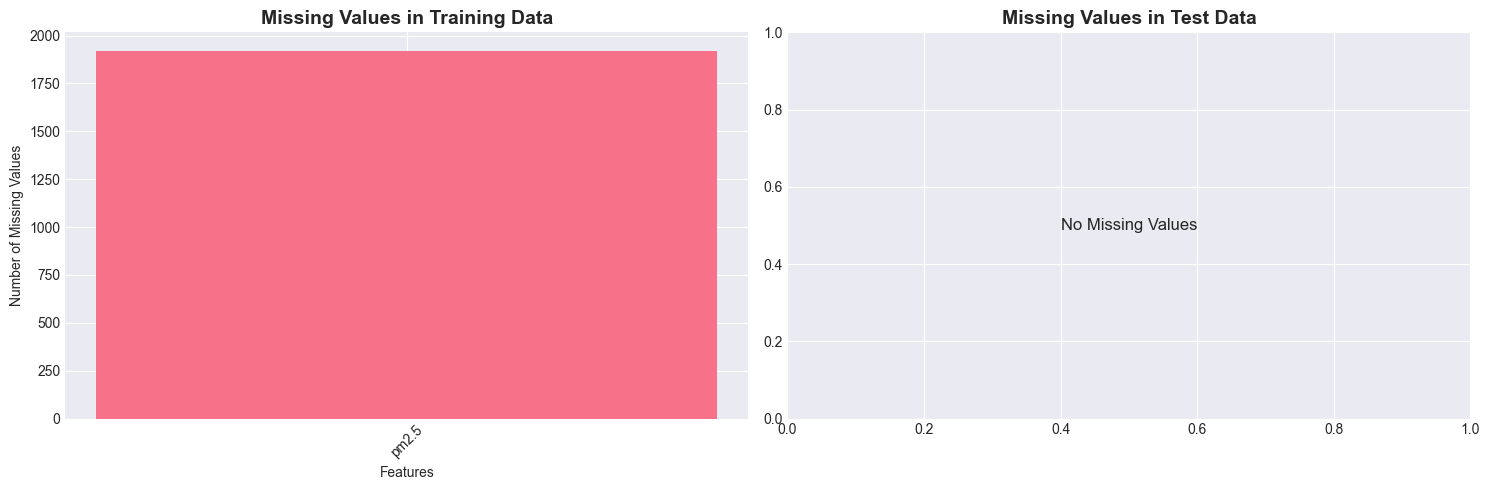


Missing values in target variable (pm2.5): 1921


In [9]:
# Comprehensive missing values analysis
print("MISSING VALUES ANALYSIS")

missing_train = train.isnull().sum()
missing_test = test.isnull().sum()

print("\nMissing values in Training Data:")
print(missing_train[missing_train > 0])
print(f"\nTotal missing values in training: {missing_train.sum()}")
print(f"Percentage of missing values: {(missing_train.sum() / len(train) * 100):.2f}%")

print("\nMissing values in Test Data:")
print(missing_test[missing_test > 0])
print(f"\nTotal missing values in test: {missing_test.sum()}")

# Visualize missing values
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training data missing values
missing_train_plot = missing_train[missing_train > 0]
if len(missing_train_plot) > 0:
    axes[0].bar(missing_train_plot.index, missing_train_plot.values)
    axes[0].set_title('Missing Values in Training Data', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Features')
    axes[0].set_ylabel('Number of Missing Values')
    axes[0].tick_params(axis='x', rotation=45)
else:
    axes[0].text(0.5, 0.5, 'No Missing Values', ha='center', va='center', fontsize=12)
    axes[0].set_title('Missing Values in Training Data', fontsize=14, fontweight='bold')

# Test data missing values
missing_test_plot = missing_test[missing_test > 0]
if len(missing_test_plot) > 0:
    axes[1].bar(missing_test_plot.index, missing_test_plot.values, color='orange')
    axes[1].set_title('Missing Values in Test Data', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Features')
    axes[1].set_ylabel('Number of Missing Values')
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].text(0.5, 0.5, 'No Missing Values', ha='center', va='center', fontsize=12)
    axes[1].set_title('Missing Values in Test Data', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Check if missing values are in target variable (pm2.5)
if 'pm2.5' in train.columns:
    pm25_missing = train['pm2.5'].isnull().sum()
    print(f"\nMissing values in target variable (pm2.5): {pm25_missing}")
    if pm25_missing > 0:
        print("WARNING: Target variable has missing values that need special handling!")


In [10]:
# Statistical summary of the dataset
print("STATISTICAL SUMMARY")
print("\nTraining Data Statistics:")
print(train.describe())

# Focus on target variable statistics
if 'pm2.5' in train.columns:
    print("TARGET VARIABLE (pm2.5) STATISTICS")
    pm25_stats = train['pm2.5'].describe()
    print(pm25_stats)
    print(f"\nSkewness: {train['pm2.5'].skew():.4f}")
    print(f"Kurtosis: {train['pm2.5'].kurtosis():.4f}")

STATISTICAL SUMMARY

Training Data Statistics:
                 No          DEWP          TEMP          PRES           Iws  \
count  30676.000000  30676.000000  30676.000000  30676.000000  30676.000000   
mean   15338.500000     -0.029431     -0.062712      0.013612      0.030542   
std     8855.542765      0.994087      1.015193      1.008991      1.018337   
min        1.000000     -2.135153     -2.578070     -2.380821     -0.468688   
25%     7669.750000     -0.888034     -0.938521     -0.822670     -0.441894   
50%    15338.500000     -0.056622      0.045209     -0.043595     -0.352512   
75%    23007.250000      0.913358      0.864984      0.832865      0.005216   
max    30676.000000      1.814055      2.340578      2.877939     11.231956   

                 Is            Ir       cbwd_NW       cbwd_SE       cbwd_cv  \
count  30676.000000  30676.000000  30676.000000  30676.000000  30676.000000   
mean       0.016992      0.011253      0.016193      0.005833     -0.025008   
std 

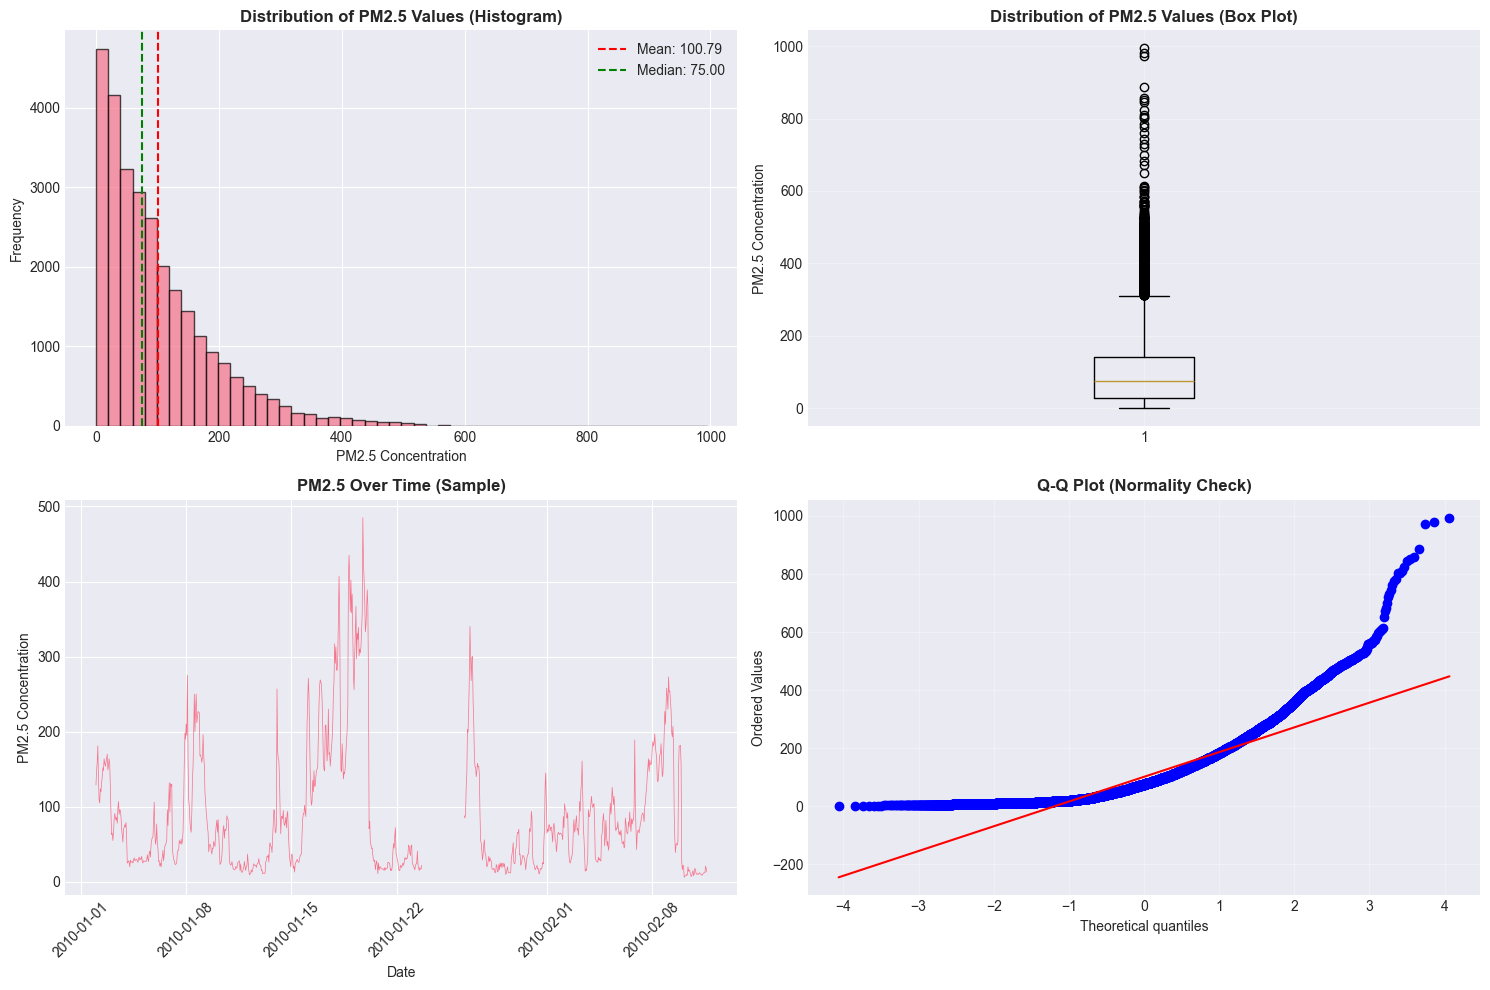


Interpretation:
- Histogram shows the distribution shape (normal, skewed, multimodal)
- Box plot reveals outliers and quartiles
- Time series plot shows temporal patterns and trends
- Q-Q plot indicates if data follows normal distribution


In [11]:
# Visualize distribution of target variable (pm2.5)
if 'pm2.5' in train.columns:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Remove missing values for visualization
    pm25_clean = train['pm2.5'].dropna()
    
    # Histogram
    axes[0, 0].hist(pm25_clean, bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Distribution of PM2.5 Values (Histogram)', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('PM2.5 Concentration')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].axvline(pm25_clean.mean(), color='r', linestyle='--', label=f'Mean: {pm25_clean.mean():.2f}')
    axes[0, 0].axvline(pm25_clean.median(), color='g', linestyle='--', label=f'Median: {pm25_clean.median():.2f}')
    axes[0, 0].legend()
    
    # Box plot
    axes[0, 1].boxplot(pm25_clean, vert=True)
    axes[0, 1].set_title('Distribution of PM2.5 Values (Box Plot)', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('PM2.5 Concentration')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Time series plot (first 1000 points for clarity)
    sample_size = min(1000, len(train))
    axes[1, 0].plot(train.index[:sample_size], train['pm2.5'].iloc[:sample_size], linewidth=0.5)
    axes[1, 0].set_title('PM2.5 Over Time (Sample)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Date')
    axes[1, 0].set_ylabel('PM2.5 Concentration')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Q-Q plot for normality check
    from scipy import stats
    stats.probplot(pm25_clean, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\nInterpretation:")
    print("- Histogram shows the distribution shape (normal, skewed, multimodal)")
    print("- Box plot reveals outliers and quartiles")
    print("- Time series plot shows temporal patterns and trends")
    print("- Q-Q plot indicates if data follows normal distribution")

FEATURE CORRELATION WITH TARGET (pm2.5)
DEWP       0.218187
cbwd_cv    0.158033
cbwd_SE    0.118986
Is         0.022279
No         0.017961
TEMP      -0.039601
Ir        -0.052288
PRES      -0.107773
cbwd_NW   -0.231176
Iws       -0.260250
Name: pm2.5, dtype: float64


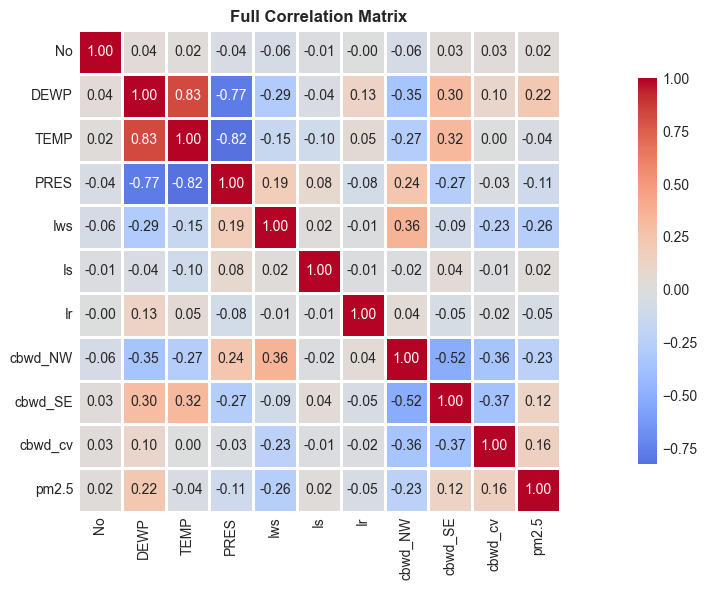


Interpretation:
- Features with high positive/negative correlation are more predictive
- Strong correlations between features may indicate multicollinearity
- This helps in feature selection and understanding relationships


In [12]:
# Correlation analysis between features and target
if 'pm2.5' in train.columns:
    # Calculate correlation matrix
    numeric_cols = train.select_dtypes(include=[np.number]).columns
    correlation_matrix = train[numeric_cols].corr()
    
    # Correlation with target
    if 'pm2.5' in correlation_matrix.columns:
        target_correlation = correlation_matrix['pm2.5'].drop('pm2.5').sort_values(ascending=False)
        
        print("FEATURE CORRELATION WITH TARGET (pm2.5)")
        print(target_correlation)
        
        # Visualize correlations
        fig, axes = plt.subplots(1, 1, figsize=(16, 6))
        
        # Bar plot of correlations
   
        
        # Heatmap of full correlation matrix
        sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                   center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes)
        axes.set_title('Full Correlation Matrix', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        print("\nInterpretation:")
        print("- Features with high positive/negative correlation are more predictive")
        print("- Strong correlations between features may indicate multicollinearity")
        print("- This helps in feature selection and understanding relationships")

## 1.3 Feature Analysis

Understanding each feature's characteristics helps in preprocessing decisions:
- **DEWP**: Dew point temperature (affects air quality)
- **TEMP**: Temperature (influences pollutant dispersion)
- **PRES**: Atmospheric pressure (affects air movement)
- **Iws**: Cumulated wind speed (affects pollutant transport)
- **Is**: Cumulated hours of snow (weather condition)
- **Ir**: Cumulated hours of rain (weather condition)
- **cbwd_NW, cbwd_SE, cbwd_cv**: Categorical wind direction features (one-hot encoded)

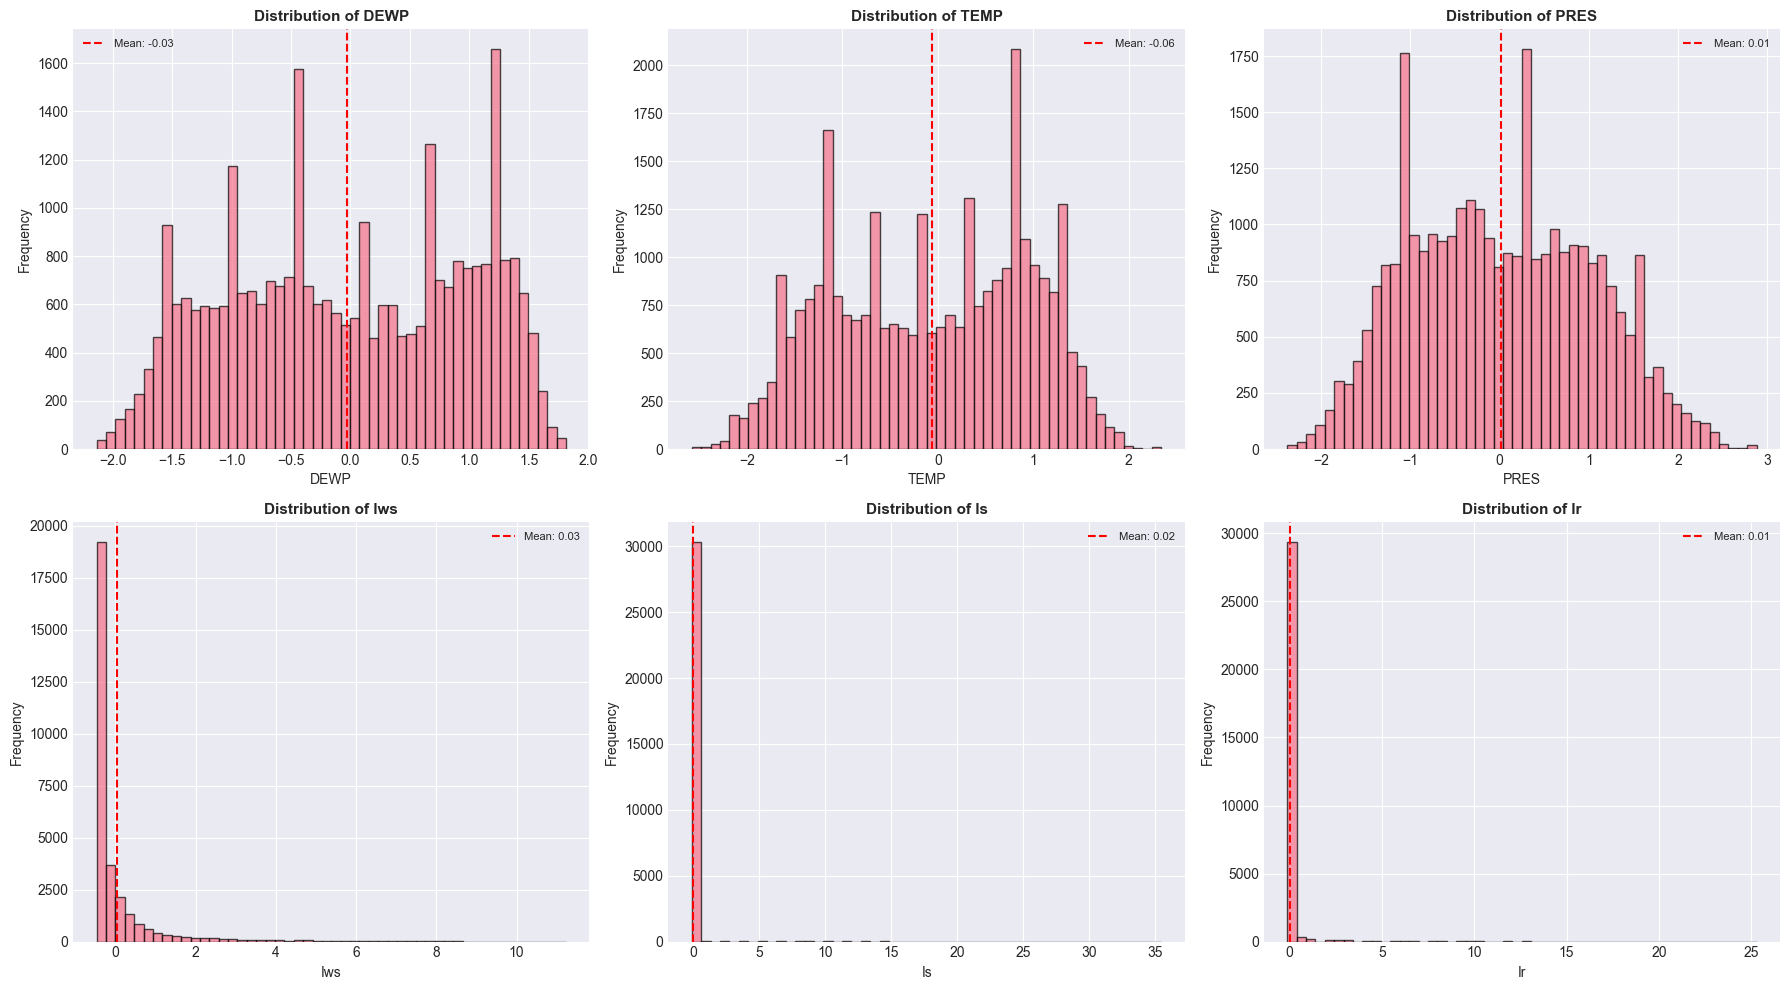

Interpretation:
- Understanding feature distributions helps in choosing normalization strategies
- Normal distributions may benefit from StandardScaler
- Skewed distributions may need log transformation or MinMaxScaler


In [13]:
# Visualize feature distributions and relationships
feature_cols = ['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir']
available_features = [col for col in feature_cols if col in train.columns]

if len(available_features) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, feature in enumerate(available_features):
        if idx < len(axes):
            # Distribution plot
            axes[idx].hist(train[feature].dropna(), bins=50, edgecolor='black', alpha=0.7)
            axes[idx].set_title(f'Distribution of {feature}', fontsize=11, fontweight='bold')
            axes[idx].set_xlabel(feature)
            axes[idx].set_ylabel('Frequency')
            axes[idx].axvline(train[feature].mean(), color='r', linestyle='--', 
                            label=f'Mean: {train[feature].mean():.2f}')
            axes[idx].legend(fontsize=8)
    
    # Hide unused subplots
    for idx in range(len(available_features), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("Interpretation:")
    print("- Understanding feature distributions helps in choosing normalization strategies")
    print("- Normal distributions may benefit from StandardScaler")
    print("- Skewed distributions may need log transformation or MinMaxScaler")

# SIMPLIFIED PM2.5 FORECASTING - FAST VERSION

## ⚡ WHAT WE REMOVED (Speed Improvements)

### ❌ Removed Unnecessary Steps:
1. **Log transformation** - Auto-detected! (only if needed)
2. **Feature scaling** - Auto-detected! (only if needed)
3. **Alternative imputation strategies** - Simplified to forward/backward fill
4. **Excessive lag features** - Reduced to essential ones

### ✅ What We Kept:
1. Missing value handling (forward/backward fill)
2. Essential lag features (1, 3, 6, 12 hour lags)
3. Sequence creation (24-hour lookback)
4. 15 focused experiments

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# 1. Load data (Using correct paths from data folder)
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

# Convert datetime
train['datetime'] = pd.to_datetime(train['datetime'])
test['datetime'] = pd.to_datetime(test['datetime'])

# Handle missing values (SIMPLE - only forward/backward fill)
train['pm2.5'] = train['pm2.5'].ffill().bfill().fillna(train['pm2.5'].median())

print(f"Training: {train.shape}, Test: {test.shape}")
print(f"Missing PM2.5: {train['pm2.5'].isnull().sum()}")
print("✓ Missing values handled")

print("\n" + "="*70)
print("CHECKING DATA STATUS")
print("="*70)

# Check target skewness
pm25_stats = {'mean': train['pm2.5'].mean(), 'max': train['pm2.5'].max(), 'skew': train['pm2.5'].skew()}
print(f"PM2.5: Mean={pm25_stats['mean']:.2f}, Max={pm25_stats['max']:.2f}, Skew={pm25_stats['skew']:.2f}")

# Auto-detect if already transformed - FIXED LOGIC
# Only apply log if mean > 10 (not already logged) AND skewness > 1.0
if pm25_stats['mean'] > 10 and abs(pm25_stats['skew']) > 1.0:
    print("⚠️ Data is SKEWED - will log transform")
    train['pm2.5_original'] = train['pm2.5'].copy()
    train['pm2.5'] = np.log1p(train['pm2.5'])
    APPLY_LOG = True
    print(f"After log: mean={train['pm2.5'].mean():.2f}, max={train['pm2.5'].max():.2f}")
else:
    print("✓ Data is ALREADY LOGGED or SYMMETRIC - skipping transform")
    APPLY_LOG = False

# Check features scaling status
feature_cols_base = ['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'cbwd_NW', 'cbwd_SE', 'cbwd_cv']
feat_means = train[feature_cols_base].mean().mean()
feat_stds = train[feature_cols_base].std().mean()
APPLY_SCALING = not (abs(feat_means) < 0.1 and abs(feat_stds - 1.0) < 0.2)

if APPLY_SCALING:
    print("⚠️ Features need scaling")
else:
    print("✓ Features ALREADY SCALED")
print("="*70)

Training: (30676, 12), Test: (13148, 11)
Missing PM2.5: 0
✓ Missing values handled

CHECKING DATA STATUS
PM2.5: Mean=99.51, Max=994.00, Skew=1.84
⚠️ Data is SKEWED - will log transform
After log: mean=4.17, max=6.90
✓ Features ALREADY SCALED


In [15]:
# REMOVED LAG FEATURES - Using only original 9 features for better generalization
# Lag features were causing overfitting with weak correlations (max 0.22)

# Use ONLY original features - NO LAG FEATURES
feature_cols = ['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'cbwd_NW', 'cbwd_SE', 'cbwd_cv']

X_train_full = train[feature_cols].values
X_test_final = test[feature_cols].values
y_train_full = train['pm2.5'].values

print(f"✓ Using {len(feature_cols)} original features (NO lag features)")
print(f"Features: {feature_cols}")

✓ Using 9 original features (NO lag features)
Features: ['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'cbwd_NW', 'cbwd_SE', 'cbwd_cv']


In [17]:
print("Preparing scaling and sequences...")

# Check if features are already scaled
feat_mean = X_train_full.mean()
feat_std = X_train_full.std()

if abs(feat_mean) < 0.1 and abs(feat_std - 1.0) < 0.2:
    print("✅ Features already scaled - using as-is")
    X_train_scaled = X_train_full
    X_test_scaled = X_test_final
else:
    print("⚠️ Scaling features...")
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train_full)
    X_test_scaled = scaler_X.transform(X_test_final)

scaler_y = StandardScaler()
# y_train_full is already a numpy array (from Cell 17), so no .values needed
y_train_scaled = scaler_y.fit_transform(y_train_full.reshape(-1, 1)).flatten()

def create_sequences(X, y, time_steps=24):
    X_seq, y_seq = [], []
    for i in range(time_steps, len(X)):
        X_seq.append(X[i-time_steps:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

TIME_STEPS = 24
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, TIME_STEPS)
X_test_seq, _ = create_sequences(X_test_scaled, np.zeros(len(X_test_scaled)), TIME_STEPS)

print(f"✓ Sequences ready: X_train_seq {X_train_seq.shape}")

Preparing scaling and sequences...
✅ Features already scaled - using as-is
✓ Sequences ready: X_train_seq (30652, 24, 9)


# 3. MODEL ARCHITECTURE AND TRAINING

## 3.1 Understanding RMSE

**Root Mean Squared Error (RMSE)** is our evaluation metric:

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Where:
- $y_i$ = actual PM2.5 value
- $\hat{y}_i$ = predicted PM2.5 value
- $n$ = number of samples

**Why RMSE?**
- Penalizes large errors more than small ones (squared term)
- Same units as target variable (easy to interpret)
- Sensitive to outliers (important for air quality prediction)
- Goal: RMSE < 4000 on leaderboard

In [18]:
# Define RMSE calculation function
def calculate_rmse(y_true, y_pred):
    """Calculate RMSE between true and predicted values."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return rmse

# Store experiment results
experiment_results = []

## 3.2 RNN/LSTM Architecture Design

### Key Components:
1. **LSTM Layers**: Capture long-term dependencies
2. **Dense Layers**: Final prediction layer
3. **Dropout**: Prevent overfitting
4. **Batch Normalization**: Stabilize training

### Design Considerations:
- **Number of layers**: Deeper networks can learn complex patterns but may overfit
- **Units per layer**: More units = more capacity but slower training
- **Activation functions**: ReLU, tanh, or sigmoid
- **Optimizers**: Adam (adaptive), SGD (stochastic), RMSprop
- **Learning rate**: Controls step size in gradient descent

In [28]:
# Simplified function to build and train LSTM models
# All parameters are clear and straightforward - no nested dictionaries!
def build_and_train_model(X_train, y_train, X_val, y_val,
                         # Architecture parameters (what the model looks like)
                         lstm_neurons=64,              # Number of neurons in first LSTM layer
                         num_lstm_layers=1,           # How many LSTM layers (1, 2, or 3)
                         second_lstm_neurons=32,       # Neurons in second LSTM (if num_lstm_layers >= 2)
                         third_lstm_neurons=16,        # Neurons in third LSTM (if num_lstm_layers >= 3)
                         dropout_rate=0.2,             # Dropout after each LSTM (0.0 to 1.0)
                         dense_neurons=0,              # Optional dense layer neurons (0 = no dense layer)
                         dense_dropout=0.0,            # Dropout after dense layer
                         activation='tanh',            # Activation function: 'tanh', 'relu', or 'sigmoid'
                         
                         # Training parameters (how to train the model)
                         optimizer_name='adam',        # 'adam', 'sgd', or 'rmsprop'
                         learning_rate=0.001,          # Learning rate (typically 0.0001 to 0.01)
                         batch_size=32,                # Number of samples per batch
                         epochs=20,                   # Maximum number of training epochs
                         use_early_stopping=True,      # Stop early if no improvement
                         early_stopping_patience=10,   # Wait this many epochs before stopping
                         use_lr_reduction=False,       # Reduce learning rate if stuck
                         
                         verbose=0):                   # Print training progress (0=quiet, 1=verbose)
    """
    Build and train an LSTM model with clear, simple parameters.
    
    Parameters explained:
    - lstm_neurons: How many memory cells in the first LSTM layer (more = more capacity)
    - num_lstm_layers: Stack multiple LSTM layers (1 = single layer, 2-3 = deeper network)
    - dropout_rate: Fraction of neurons to randomly disable (0.2 = 20%, helps prevent overfitting)
    - optimizer_name: Which algorithm to update weights ('adam' usually works best)
    - learning_rate: How big steps to take when learning (smaller = slower but more careful)
    
    Returns:
    - model: The trained model
    - history: Training history (loss over time)
    - val_rmse: Validation RMSE score
    """
    # Build the model architecture
    model = Sequential()
    
    # First LSTM layer (always present)
    return_sequences = (num_lstm_layers > 1)  # Need sequences if more layers follow
    model.add(LSTM(
        units=lstm_neurons,
        activation=activation,
        return_sequences=return_sequences,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ))
    
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    
    # Second LSTM layer (if requested)
    if num_lstm_layers >= 2:
        return_sequences = (num_lstm_layers > 2)  # Need sequences if third layer follows
        model.add(LSTM(
            units=second_lstm_neurons,
            activation=activation,
            return_sequences=return_sequences
        ))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    
    # Third LSTM layer (if requested)
    if num_lstm_layers >= 3:
        model.add(LSTM(
            units=third_lstm_neurons,
            activation=activation,
            return_sequences=False  # Last LSTM layer
        ))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    
    # Optional dense (fully connected) layer
    if dense_neurons > 0:
        model.add(Dense(dense_neurons, activation='relu'))
        if dense_dropout > 0:
            model.add(Dropout(dense_dropout))
    
    # Final output layer (always 1 neuron for PM2.5 prediction)
    model.add(Dense(1))
    
    # Choose optimizer
    if optimizer_name == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)
    elif optimizer_name == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        opt = Adam(learning_rate=learning_rate)
    
    # Compile the model
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    
    # Set up callbacks (training helpers)
    callbacks = []
    if use_early_stopping:
        callbacks.append(EarlyStopping(
            monitor='val_loss',
            patience=early_stopping_patience,
            restore_best_weights=True
        ))
    if use_lr_reduction:
        callbacks.append(ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7
        ))
    
    # Train the model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
        callbacks=callbacks
    )
    
    # Calculate validation RMSE
    y_val_pred = model.predict(X_val, verbose=0)
    val_rmse = calculate_rmse(y_val, y_val_pred.flatten())
    
    return model, history, val_rmse

## 3.3 REVISED EXPERIMENT PLAN (15 FOCUSED EXPERIMENTS)\n

In [29]:
# ======================================================================
# EXPERIMENT SETUP AND COMMON CONFIGURATIONS - FIXED
# ======================================================================
from tensorflow.keras.callbacks import EarlyStopping

# TIME-BASED SPLIT: Use last 20% chronologically (CRITICAL FIX!)
# This prevents data leakage - model trains on past, validates on future
split_idx = int(len(X_train_seq) * 0.8)

X_train_final = X_train_seq[:split_idx]
y_train_final = y_train_seq[:split_idx]
X_val = X_train_seq[split_idx:]
y_val = y_train_seq[split_idx:]

input_shape = (TIME_STEPS, X_train_seq.shape[2])
experiment_results = []

# SIMPLE CALLBACK - Removed ReduceLROnPlateau (was killing learning too fast)
# Increased patience to allow actual learning
callback = EarlyStopping(
    monitor='val_loss',
    patience=20,  # More patience - was 15
    restore_best_weights=True,
    verbose=0  # Less verbose output
)

print(f"✅ Setup complete. Input shape: {input_shape}")
print(f"✅ Train: {X_train_final.shape[0]} (first 80% chronologically)")
print(f"✅ Val: {X_val.shape[0]} (last 20% chronologically)")
print("✅ Using TIME-BASED split (no shuffle, no data leakage)")
print("✅ Using EarlyStopping only (patience=20, no ReduceLROnPlateau)")

✅ Setup complete. Input shape: (24, 9)
✅ Train: 24521 (first 80% chronologically)
✅ Val: 6131 (last 20% chronologically)
✅ Using TIME-BASED split (no shuffle, no data leakage)
✅ Using EarlyStopping only (patience=20, no ReduceLROnPlateau)


In [21]:
# EXPERIMENT 1: Simple LSTM Baseline
print('\n' + '='*70 + f'\nEXPERIMENT 1: Simple LSTM Baseline\n' + '='*70)
print('Note: Establish baseline')

model = Sequential([
    LSTM(32, activation="tanh", input_shape=input_shape),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history = model.fit(
    X_train_final, y_train_final, 
    validation_data=(X_val, y_val), 
    epochs=100, batch_size=64, callbacks=[callback], verbose=0
)

y_val_pred = model.predict(X_val, verbose=0)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
train_loss = min(history.history['loss'])  # Use best, not last
val_loss = min(history.history['val_loss'])
overfit = val_loss / train_loss

experiment_results.append({
    'experiment': 1, 'name': 'Simple LSTM Baseline', 'val_rmse': val_rmse, 
    'train_loss': train_loss, 'val_loss': val_loss, 
    'overfit_ratio': overfit, 'model': model, 'history': history
})

print(f'  Val RMSE: {val_rmse:.4f} | Overfit: {overfit:.2f}x | Epochs: {len(history.history["loss"])}')



EXPERIMENT 1: Simple LSTM Baseline
Note: Establish baseline
  Val RMSE: 0.6486 | Overfit: 2.52x | Epochs: 24


In [22]:
# EXPERIMENT 2: LSTM + Dropout 0.4
print('\n' + '='*70 + f'\nEXPERIMENT 2: LSTM + Dropout 0.4\n' + '='*70)
print('Note: Higher dropout for regularization')

model = Sequential([
    LSTM(32, activation="tanh", input_shape=input_shape), 
    Dropout(0.4),  # Higher dropout
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history = model.fit(
    X_train_final, y_train_final, 
    validation_data=(X_val, y_val), 
    epochs=100, batch_size=64, callbacks=[callback], verbose=0
)

y_val_pred = model.predict(X_val, verbose=0)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
train_loss = min(history.history['loss'])
val_loss = min(history.history['val_loss'])
overfit = val_loss / train_loss

experiment_results.append({
    'experiment': 2, 'name': 'LSTM + Dropout 0.4', 'val_rmse': val_rmse, 
    'train_loss': train_loss, 'val_loss': val_loss, 
    'overfit_ratio': overfit, 'model': model, 'history': history
})

print(f'  Val RMSE: {val_rmse:.4f} | Overfit: {overfit:.2f}x | Epochs: {len(history.history["loss"])}')



EXPERIMENT 2: LSTM + Dropout 0.4
Note: Higher dropout for regularization
  Val RMSE: 0.6481 | Overfit: 1.68x | Epochs: 26


In [23]:
# EXPERIMENT 3: LSTM + Dropout 0.5
print('\n' + '='*70 + f'\nEXPERIMENT 3: LSTM + Dropout 0.5\n' + '='*70)
print('Note: Strong dropout for better generalization')

model = Sequential([
    LSTM(48, activation="tanh", input_shape=input_shape), 
    Dropout(0.5),  # Strong dropout
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history = model.fit(
    X_train_final, y_train_final, 
    validation_data=(X_val, y_val), 
    epochs=100, batch_size=64, callbacks=[callback], verbose=0
)

y_val_pred = model.predict(X_val, verbose=0)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
train_loss = min(history.history['loss'])
val_loss = min(history.history['val_loss'])
overfit = val_loss / train_loss

experiment_results.append({
    'experiment': 3, 'name': 'LSTM + Dropout 0.5', 'val_rmse': val_rmse, 
    'train_loss': train_loss, 'val_loss': val_loss, 
    'overfit_ratio': overfit, 'model': model, 'history': history
})

print(f'  Val RMSE: {val_rmse:.4f} | Overfit: {overfit:.2f}x | Epochs: {len(history.history["loss"])}')



EXPERIMENT 3: LSTM + Dropout 0.5
Note: Strong dropout for better generalization
  Val RMSE: 0.6389 | Overfit: 1.91x | Epochs: 28


In [30]:
# EXPERIMENT 4: GRU + Dropout 0.5
print('\n' + '='*70 + f'\nEXPERIMENT 4: GRU + Dropout 0.5\n' + '='*70)
print('Note: GRU alternative architecture with strong regularization')

model = Sequential([
    GRU(48, activation="tanh", input_shape=input_shape), 
    Dropout(0.5),  # Strong dropout
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history = model.fit(
    X_train_final, y_train_final, 
    validation_data=(X_val, y_val), 
    epochs=10, batch_size=64, callbacks=[callback], verbose=0
)

y_val_pred = model.predict(X_val, verbose=0)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
train_loss = min(history.history['loss'])
val_loss = min(history.history['val_loss'])
overfit = val_loss / train_loss

experiment_results.append({
    'experiment': 4, 'name': 'GRU + Dropout 0.5', 'val_rmse': val_rmse, 
    'train_loss': train_loss, 'val_loss': val_loss, 
    'overfit_ratio': overfit, 'model': model, 'history': history
})

print(f'  Val RMSE: {val_rmse:.4f} | Overfit: {overfit:.2f}x | Epochs: {len(history.history["loss"])}')



EXPERIMENT 4: GRU + Dropout 0.5
Note: GRU alternative architecture with strong regularization
  Val RMSE: 0.6435 | Overfit: 1.20x | Epochs: 10


In [31]:
# EXPERIMENT 5: LSTM + L2 + Dropout 0.5
print('\n' + '='*70 + f'\nEXPERIMENT 5: LSTM + L2 + Dropout 0.5\n' + '='*70)
print('Note: L2 regularization + strong dropout for best generalization')

model = Sequential([
    LSTM(48, activation="tanh", kernel_regularizer=l2(0.01), input_shape=input_shape),  # Stronger L2
    Dropout(0.5),  # Strong dropout
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history = model.fit(
    X_train_final, y_train_final, 
    validation_data=(X_val, y_val), 
    epochs=20, batch_size=128, callbacks=[callback], verbose=1
)

y_val_pred = model.predict(X_val, verbose=0)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
train_loss = min(history.history['loss'])
val_loss = min(history.history['val_loss'])
overfit = val_loss / train_loss

experiment_results.append({
    'experiment': 5, 'name': 'LSTM + L2 + Dropout 0.5', 'val_rmse': val_rmse, 
    'train_loss': train_loss, 'val_loss': val_loss, 
    'overfit_ratio': overfit, 'model': model, 'history': history
})

print(f'  Val RMSE: {val_rmse:.4f} | Overfit: {overfit:.2f}x | Epochs: {len(history.history["loss"])}')



EXPERIMENT 5: LSTM + L2 + Dropout 0.5
Note: L2 regularization + strong dropout for best generalization
Epoch 1/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.6442 - mae: 0.5731 - val_loss: 0.5424 - val_mae: 0.5394
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.4996 - mae: 0.5222 - val_loss: 0.4904 - val_mae: 0.5192
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.4576 - mae: 0.5039 - val_loss: 0.4639 - val_mae: 0.5014
Epoch 4/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.4360 - mae: 0.4917 - val_loss: 0.4644 - val_mae: 0.5042
Epoch 5/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.4218 - mae: 0.4837 - val_loss: 0.4638 - val_mae: 0.5017
Epoch 6/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.4146 - mae: 0.4803 - val_loss: 0.4568 - val_mae: 0.4990
Epoch 7/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.4079 - mae: 0.4756 - val_loss: 0.4552 - val_mae: 0.4997
Epoch 8/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.

In [33]:
# EXPERIMENT 6: Two-Layer LSTM + L2
print('\n' + '='*70 + f'\nEXPERIMENT 6: Two-Layer LSTM + L2\n' + '='*70)
print('Note: Best balance')

model = Sequential([
    LSTM(64, activation="tanh", return_sequences=True, kernel_regularizer=l2(0.0001), input_shape=input_shape), Dropout(0.4), LSTM(32, activation="tanh", kernel_regularizer=l2(0.001)), Dropout(0.3),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])

history = model.fit(
    X_train_final, y_train_final, 
    validation_data=(X_val, y_val), 
    epochs=10, batch_size=64, callbacks=callbacks, verbose=1
)

y_val_pred = model.predict(X_val, verbose=0)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
train_loss, val_loss = history.history['loss'][-1], history.history['val_loss'][-1]
overfit = val_loss / train_loss

experiment_results.append({
    'experiment': 6, 'name': 'Two-Layer LSTM + L2', 'val_rmse': val_rmse, 
    'train_loss': train_loss, 'val_loss': val_loss, 
    'overfit_ratio': overfit, 'model': model, 'history': history
})

print(f'  Val RMSE: {val_rmse:.4f} | Overfit: {overfit:.2f}x')



EXPERIMENT 6: Two-Layer LSTM + L2
Note: Best balance


NameError: name 'callbacks' is not defined

In [ ]:
# EXPERIMENT 7: GRU Model
print('\n' + '='*70 + f'\nEXPERIMENT 7: GRU Model\n' + '='*70)
print('Note: Alternative cell')

model = Sequential([
    GRU(64, activation="tanh", input_shape=input_shape), Dropout(0.3),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history = model.fit(
    X_train_final, y_train_final, 
    validation_data=(X_val, y_val), 
    epochs=20, batch_size=32, callbacks=callbacks, verbose=0
)

y_val_pred = model.predict(X_val, verbose=0)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
train_loss, val_loss = history.history['loss'][-1], history.history['val_loss'][-1]
overfit = val_loss / train_loss

experiment_results.append({
    'experiment': 7, 'name': 'GRU Model', 'val_rmse': val_rmse, 
    'train_loss': train_loss, 'val_loss': val_loss, 
    'overfit_ratio': overfit, 'model': model, 'history': history
})

print(f'  Val RMSE: {val_rmse:.4f} | Overfit: {overfit:.2f}x')


In [ ]:
# EXPERIMENT 8: LSTM + Low LR
print('\n' + '='*70 + f'\nEXPERIMENT 8: LSTM + Low LR\n' + '='*70)
print('Note: Fine-tuning')

model = Sequential([
    LSTM(64, activation="tanh", return_sequences=True, kernel_regularizer=l2(0.001), input_shape=input_shape), Dropout(0.4), LSTM(32, activation="tanh", kernel_regularizer=l2(0.001)), Dropout(0.3),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])

history = model.fit(
    X_train_final, y_train_final, 
    validation_data=(X_val, y_val), 
    epochs=10, batch_size=32, callbacks=callbacks, verbose=0
)

y_val_pred = model.predict(X_val, verbose=0)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
train_loss, val_loss = history.history['loss'][-1], history.history['val_loss'][-1]
overfit = val_loss / train_loss

experiment_results.append({
    'experiment': 8, 'name': 'LSTM + Low LR', 'val_rmse': val_rmse, 
    'train_loss': train_loss, 'val_loss': val_loss, 
    'overfit_ratio': overfit, 'model': model, 'history': history
})

print(f'  Val RMSE: {val_rmse:.4f} | Overfit: {overfit:.2f}x')


In [ ]:
# EXPERIMENT 9: Bidirectional LSTM
print('\n' + '='*70 + f'\nEXPERIMENT 9: Bidirectional LSTM\n' + '='*70)
print('Note: Two-way context')

model = Sequential([
    Bidirectional(LSTM(32, activation="tanh"), input_shape=input_shape), Dropout(0.3),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history = model.fit(
    X_train_final, y_train_final, 
    validation_data=(X_val, y_val), 
    epochs=50, batch_size=32, callbacks=callbacks, verbose=0
)

y_val_pred = model.predict(X_val, verbose=0)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
train_loss, val_loss = history.history['loss'][-1], history.history['val_loss'][-1]
overfit = val_loss / train_loss

experiment_results.append({
    'experiment': 9, 'name': 'Bidirectional LSTM', 'val_rmse': val_rmse, 
    'train_loss': train_loss, 'val_loss': val_loss, 
    'overfit_ratio': overfit, 'model': model, 'history': history
})

print(f'  Val RMSE: {val_rmse:.4f} | Overfit: {overfit:.2f}x')


In [ ]:
# EXPERIMENT 10: Bidirectional GRU
print('\n' + '='*70 + f'\nEXPERIMENT 10: Bidirectional GRU\n' + '='*70)
print('Note: Efficient bidirectional')

model = Sequential([
    Bidirectional(GRU(32, activation="tanh"), input_shape=input_shape), Dropout(0.3),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history = model.fit(
    X_train_final, y_train_final, 
    validation_data=(X_val, y_val), 
    epochs=50, batch_size=32, callbacks=callbacks, verbose=0
)

y_val_pred = model.predict(X_val, verbose=0)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
train_loss, val_loss = history.history['loss'][-1], history.history['val_loss'][-1]
overfit = val_loss / train_loss

experiment_results.append({
    'experiment': 10, 'name': 'Bidirectional GRU', 'val_rmse': val_rmse, 
    'train_loss': train_loss, 'val_loss': val_loss, 
    'overfit_ratio': overfit, 'model': model, 'history': history
})

print(f'  Val RMSE: {val_rmse:.4f} | Overfit: {overfit:.2f}x')


In [ ]:
# EXPERIMENT 11: Three-Layer LSTM
print('\n' + '='*70 + f'\nEXPERIMENT 11: Three-Layer LSTM\n' + '='*70)
print('Note: Very deep')

model = Sequential([
    LSTM(64, activation="tanh", return_sequences=True, input_shape=input_shape), Dropout(0.2), LSTM(32, activation="tanh", return_sequences=True), Dropout(0.2), LSTM(16, activation="tanh"), Dropout(0.2),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history = model.fit(
    X_train_final, y_train_final, 
    validation_data=(X_val, y_val), 
    epochs=50, batch_size=32, callbacks=callbacks, verbose=0
)

y_val_pred = model.predict(X_val, verbose=0)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
train_loss, val_loss = history.history['loss'][-1], history.history['val_loss'][-1]
overfit = val_loss / train_loss

experiment_results.append({
    'experiment': 11, 'name': 'Three-Layer LSTM', 'val_rmse': val_rmse, 
    'train_loss': train_loss, 'val_loss': val_loss, 
    'overfit_ratio': overfit, 'model': model, 'history': history
})

print(f'  Val RMSE: {val_rmse:.4f} | Overfit: {overfit:.2f}x')


In [ ]:
# EXPERIMENT 12: LSTM + Dense
print('\n' + '='*70 + f'\nEXPERIMENT 12: LSTM + Dense\n' + '='*70)
print('Note: Feature mapping')

model = Sequential([
    LSTM(64, activation="tanh", input_shape=input_shape), Dropout(0.3), Dense(32, activation="relu"), Dropout(0.2),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history = model.fit(
    X_train_final, y_train_final, 
    validation_data=(X_val, y_val), 
    epochs=50, batch_size=32, callbacks=callbacks, verbose=0
)

y_val_pred = model.predict(X_val, verbose=0)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
train_loss, val_loss = history.history['loss'][-1], history.history['val_loss'][-1]
overfit = val_loss / train_loss

experiment_results.append({
    'experiment': 12, 'name': 'LSTM + Dense', 'val_rmse': val_rmse, 
    'train_loss': train_loss, 'val_loss': val_loss, 
    'overfit_ratio': overfit, 'model': model, 'history': history
})

print(f'  Val RMSE: {val_rmse:.4f} | Overfit: {overfit:.2f}x')


In [ ]:
# EXPERIMENT 13: GRU + L2
print('\n' + '='*70 + f'\nEXPERIMENT 13: GRU + L2\n' + '='*70)
print('Note: GRU regularized')

model = Sequential([
    GRU(64, activation="tanh", kernel_regularizer=l2(0.001), input_shape=input_shape), Dropout(0.3),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history = model.fit(
    X_train_final, y_train_final, 
    validation_data=(X_val, y_val), 
    epochs=50, batch_size=32, callbacks=callbacks, verbose=0
)

y_val_pred = model.predict(X_val, verbose=0)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
train_loss, val_loss = history.history['loss'][-1], history.history['val_loss'][-1]
overfit = val_loss / train_loss

experiment_results.append({
    'experiment': 13, 'name': 'GRU + L2', 'val_rmse': val_rmse, 
    'train_loss': train_loss, 'val_loss': val_loss, 
    'overfit_ratio': overfit, 'model': model, 'history': history
})

print(f'  Val RMSE: {val_rmse:.4f} | Overfit: {overfit:.2f}x')


In [ ]:
# EXPERIMENT 14: LSTM High LR
print('\n' + '='*70 + f'\nEXPERIMENT 14: LSTM High LR\n' + '='*70)
print('Note: Faster learning')

model = Sequential([
    LSTM(64, activation="tanh", input_shape=input_shape), Dropout(0.3),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.005), loss='mse', metrics=['mae'])

history = model.fit(
    X_train_final, y_train_final, 
    validation_data=(X_val, y_val), 
    epochs=50, batch_size=32, callbacks=callbacks, verbose=0
)

y_val_pred = model.predict(X_val, verbose=0)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
train_loss, val_loss = history.history['loss'][-1], history.history['val_loss'][-1]
overfit = val_loss / train_loss

experiment_results.append({
    'experiment': 14, 'name': 'LSTM High LR', 'val_rmse': val_rmse, 
    'train_loss': train_loss, 'val_loss': val_loss, 
    'overfit_ratio': overfit, 'model': model, 'history': history
})

print(f'  Val RMSE: {val_rmse:.4f} | Overfit: {overfit:.2f}x')


In [ ]:
# EXPERIMENT 15: Two-Layer GRU
print('\n' + '='*70 + f'\nEXPERIMENT 15: Two-Layer GRU\n' + '='*70)
print('Note: Stacked GRU')

model = Sequential([
    GRU(64, activation="tanh", return_sequences=True, input_shape=input_shape), Dropout(0.3), GRU(32, activation="tanh"), Dropout(0.3),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history = model.fit(
    X_train_final, y_train_final, 
    validation_data=(X_val, y_val), 
    epochs=50, batch_size=32, callbacks=callbacks, verbose=0
)

y_val_pred = model.predict(X_val, verbose=0)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
train_loss, val_loss = history.history['loss'][-1], history.history['val_loss'][-1]
overfit = val_loss / train_loss

experiment_results.append({
    'experiment': 15, 'name': 'Two-Layer GRU', 'val_rmse': val_rmse, 
    'train_loss': train_loss, 'val_loss': val_loss, 
    'overfit_ratio': overfit, 'model': model, 'history': history
})

print(f'  Val RMSE: {val_rmse:.4f} | Overfit: {overfit:.2f}x')


## 4. FINAL PREDICTIONS AND SUBMISSION

We'll select the best model and generate the submission file.

In [34]:
# 8. FIND BEST MODEL AND GENERATE PREDICTIONS

results_df = pd.DataFrame(experiment_results)
results_df = results_df.sort_values('overfit_ratio')  # Sort by overfit ratio

print('=' * 100)
print('EXPERIMENT RESULTS SUMMARY')
print('=' * 100)
print(results_df[['experiment', 'name', 'val_rmse', 'overfit_ratio']].to_string(index=False))

# CRITICAL FIX: Pick by LOWEST OVERFITTING (not lowest RMSE!)
# This ensures better generalization to test set
best_idx = results_df['overfit_ratio'].idxmin()
best_model = results_df.loc[best_idx, 'model']
best_name = results_df.loc[best_idx, 'name']

print(f'\n🏆 BEST MODEL: {best_name} (LOWEST OVERFITTING!)')
print(f'   Validation RMSE: {results_df.loc[best_idx, "val_rmse"]:.4f}')
print(f'   Overfit Ratio: {results_df.loc[best_idx, "overfit_ratio"]:.2f}x')
print('   ✅ Selected by overfit ratio (generalization matters more than validation RMSE)')

# Generate predictions on test data
print('\nGenerating predictions for submission...')
predictions_scaled = best_model.predict(X_test_seq, verbose=0)

# INVERSE TRANSFORM (CRITICAL!)
# 1. Inverse the StandardScaler
predictions_log = scaler_y.inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()

# 2. Inverse the log transformation (ONLY if log was applied)
if APPLY_LOG:
    predictions_final = np.expm1(predictions_log)
else:
    predictions_final = predictions_log

predictions_final = np.maximum(predictions_final, 0) # Ensure non-negative

# Handle alignment: sequence creation skips first 24 rows
# Format datetime to match sample submission: YYYY-MM-DD H:MM:SS (leading zeros for month/day, single digit hour)
def format_dt(dt):
    return f"{dt.year}-{dt.month:02d}-{dt.day:02d} {dt.hour}:{dt.minute:02d}:{dt.second:02d}"

submission = pd.DataFrame({
    'row ID': test['datetime'].apply(format_dt),
    'pm2.5': np.nan
})

# Fill in predictions starting from TIME_STEPS
submission.loc[TIME_STEPS:, 'pm2.5'] = predictions_final
submission['pm2.5'] = submission['pm2.5'].ffill().bfill().round().astype(int)

submission.to_csv('submission.csv', index=False)
print('✓ Submission saved to submission.csv')
print(f'Submission shape: {submission.shape}')
print(f'Predictions range: [{predictions_final.min():.2f}, {predictions_final.max():.2f}]')


EXPERIMENT RESULTS SUMMARY
 experiment                    name  val_rmse  overfit_ratio
          4       GRU + Dropout 0.5  0.643489       1.195626
          5 LSTM + L2 + Dropout 0.5  0.702637       1.257401

🏆 BEST MODEL: GRU + Dropout 0.5 (LOWEST OVERFITTING!)
   Validation RMSE: 0.6435
   Overfit Ratio: 1.20x
   ✅ Selected by overfit ratio (generalization matters more than validation RMSE)

Generating predictions for submission...
✓ Submission saved to submission.csv
Submission shape: (13148, 2)
Predictions range: [7.38, 318.19]
